In [1]:
#URL = https://www.kaggle.com/competitions/digit-recognizer/overview

In [ ]:
import pandas as pd

dataset = pd.read_csv('https://huggingface.co/datasets/NHANGIOI/Learning-Training/resolve/main/Digit_Recognizer/train.csv')
x_train = dataset.drop(columns = 'label')
y_train = dataset['label']

In [11]:
x_train = x_train.values.reshape(-1,28,28,1)

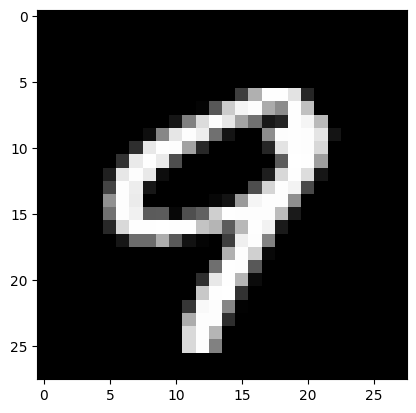

In [4]:
import matplotlib.pyplot as plt

plt.imshow(x_train.iloc[100].values.reshape(28,28), cmap='gray')
plt.show()

In [6]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

model = keras.Sequential([
    layers.Conv2D(filters = 32,kernel_size = 3,strides = 1,padding = 'same',activation = 'relu',input_shape = (28,28,1)),
    layers.MaxPool2D(pool_size = 3,strides = 1,padding = 'same'),
    
    layers.Conv2D(filters = 64,kernel_size = 3,strides = 1,padding = 'same',activation = 'relu'),
    layers.MaxPool2D(pool_size = 3,strides = 1,padding = 'same'),
    
    layers.Conv2D(filters = 128,kernel_size = 3,strides = 1,padding = 'same',activation = 'relu'),
    layers.MaxPool2D(pool_size = 3,strides = 1,padding = 'same'),
    
    layers.Flatten(),
    layers.BatchNormalization(),
    layers.Dropout(rate = 0.25),
    layers.Dense(units = 64,activation = 'relu'),
    layers.Dense(units = 10,activation = 'softmax')
])


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [15]:
model.compile(
    optimizer = tf.keras.optimizers.Adam(),
    loss = 'sparse_categorical_crossentropy',
    metrics = ['accuracy']
)

In [20]:
history = model.fit(
    x_train,
    y_train,
    validation_split = 0.2,
    epochs = 25
)

Epoch 1/25
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 14s 14ms/step - accuracy: 0.9924 - loss: 0.0308 - val_accuracy: 0.9921 - val_loss: 0.1155
Epoch 2/25
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 13s 12ms/step - accuracy: 0.9935 - loss: 0.0250 - val_accuracy: 0.9929 - val_loss: 1.1649
Epoch 3/25
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 13s 12ms/step - accuracy: 0.9940 - loss: 0.0224 - val_accuracy: 0.9933 - val_loss: 0.1586
Epoch 4/25
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 12s 12ms/step - accuracy: 0.9946 - loss: 0.0217 - val_accuracy: 0.9873 - val_loss: 1.7143
Epoch 5/25
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 12s 12ms/step - accuracy: 0.9937 - loss: 0.0259 - val_accuracy: 0.9908 - val_loss: 1.3090
Epoch 6/25
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 12s 12ms/step - accuracy: 0.9932 - loss: 0.0328 - val_accuracy: 0.9944 - val_loss: 0.5791
Epoch 7/25
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 12s 12ms/step - accuracy: 0.9942 - loss: 0.0235 - val_accuracy: 0.9929 - val_loss: 1.2339
Epoch 8/25
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 13s 12ms/step - accuracy: 0.9958 -

In [21]:
history.history.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

<Axes: >

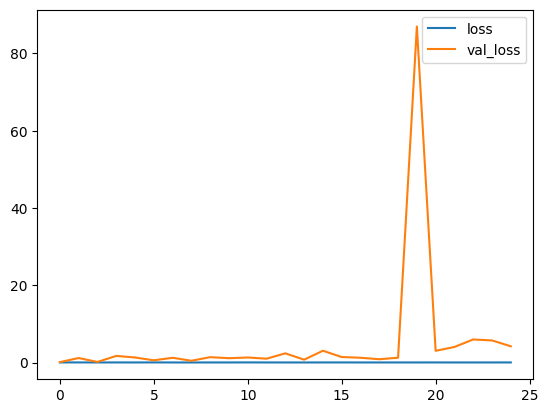

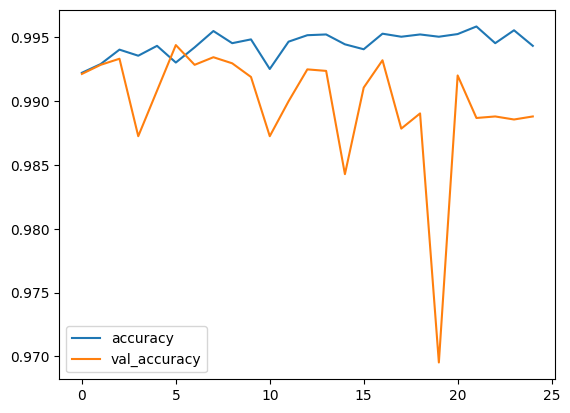

In [22]:
history_frame = pd.DataFrame(history.history)
history_frame.loc[:, ['loss', 'val_loss']].plot()
history_frame.loc[:, ['accuracy', 'val_accuracy']].plot()

In [24]:
import numpy as np
x_test = pd.read_csv('https://huggingface.co/datasets/NHANGIOI/Learning-Training/resolve/main/Digit_Recognizer/test.csv')
x_test = x_test.values.reshape(-1,28,28,1)
pred = model.predict(x_test)
pred = np.argmax(pred, axis=1)

submission = pd.DataFrame({
    "ImageId" : [id for id in range(1,x_test.shape[0] + 1)],
    "Label" : pred
})
submission.to_csv('submission.csv',index = False)

875/875 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step
